# 1. Data loading

In [149]:
# Install dependencies
!pip install wfdb

In [150]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [151]:
import os
import zipfile

zip_path = "/content/drive/MyDrive/ptbxl.zip"
extract_path = "/content/ptbxl"

# Only unzip if not already extracted in this session
if not os.path.exists(extract_path):
    print("Copying zip to local storage...")
    !cp "{zip_path}" /content/

    print("Unzipping...")
    with zipfile.ZipFile("/content/ptbxl.zip", 'r') as zip_ref:
        zip_ref.extractall("/content/")

    print("Done.")
else:
    print("Dataset already available in local session.")

Copying zip to local storage...
Unzipping...
Done.


In [152]:
path = "/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"

In [153]:
import pandas as pd
import numpy as np
import wfdb
import ast
import os
import matplotlib.pyplot as plt

def load_raw_data(df, sampling_rate, path):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(path + f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(path + f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

sampling_rate = 100

# Load and convert annotation data
Y = pd.read_csv(path + 'ptbxl_database.csv', index_col='ecg_id')
Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

# Load raw signal data
X = load_raw_data(Y, sampling_rate, path)

# Load scp_statements.csv for diagnostic aggregation
agg_df = pd.read_csv(path + 'scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]

def aggregate_diagnostic(y_dic):
    tmp = []
    for key in y_dic.keys():
        if key in agg_df.index:
            tmp.append(agg_df.loc[key].diagnostic_class)
    return list(set(tmp))

# Apply diagnostic superclass
Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

# Split data into train, validation, and test according to PTB-XL folds
train_folds = list(range(1, 9))   # 1–8
val_fold = 9                      # 9
test_fold = 10                    # 10

# Train
X_train = X[np.where(Y.strat_fold.isin(train_folds))]
y_train = Y[Y.strat_fold.isin(train_folds)].diagnostic_superclass

# Validation
X_val = X[np.where(Y.strat_fold == val_fold)]
y_val = Y[Y.strat_fold == val_fold].diagnostic_superclass

# Test
X_test = X[np.where(Y.strat_fold == test_fold)]
y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

print("X_train shape:", X_train.shape)
print("y_train sample:", y_train.head())

print("X_val shape:", X_val.shape)
print("y_val sample:", y_val.head())

print("X_test shape:", X_test.shape)
print("y_test sample:", y_test.head())


X_train shape: (17418, 1000, 12)
y_train sample: ecg_id
1    [NORM]
2    [NORM]
3    [NORM]
4    [NORM]
5    [NORM]
Name: diagnostic_superclass, dtype: object
X_val shape: (2183, 1000, 12)
y_val sample: ecg_id
8       [MI]
10    [NORM]
17        []
18        []
20        []
Name: diagnostic_superclass, dtype: object
X_test shape: (2198, 1000, 12)
y_test sample: ecg_id
9     [NORM]
38    [NORM]
40    [NORM]
57    [NORM]
59    [NORM]
Name: diagnostic_superclass, dtype: object


In [154]:
folder_path = path + "records100/00000"

# List all .hea files (each one corresponds to one ECG)
records = [f.replace(".hea", "") for f in os.listdir(folder_path) if f.endswith(".hea")]

print("Found records:", records[:10])

Found records: ['00262_lr', '00376_lr', '00404_lr', '00238_lr', '00701_lr', '00779_lr', '00279_lr', '00538_lr', '00968_lr', '00707_lr']


# 2. Exploratory Data Analysis (EDA)

### 2.1. General overview

In [155]:
# Load metadata
path = "/content/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/"
df = pd.read_csv(path + "ptbxl_database.csv", index_col="ecg_id")

print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nFirst 5 rows:")
display(df.head())


Shape of dataset: (21799, 27)

Columns:
Index(['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site',
       'device', 'recording_date', 'report', 'scp_codes', 'heart_axis',
       'infarction_stadium1', 'infarction_stadium2', 'validated_by',
       'second_opinion', 'initial_autogenerated_report', 'validated_by_human',
       'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems',
       'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr'],
      dtype='str')

Data types:
patient_id                      float64
age                             float64
sex                               int64
height                          float64
weight                          float64
nurse                           float64
site                            float64
device                              str
recording_date                      str
report                              str
scp_codes                           str
heart_axis                          s

,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


### 2.2. Demographic analysis

Age statistics:
count    21799.000000
mean        62.769301
std         32.308813
min          2.000000
25%         50.000000
50%         62.000000
75%         72.000000
max        300.000000
Name: age, dtype: float64


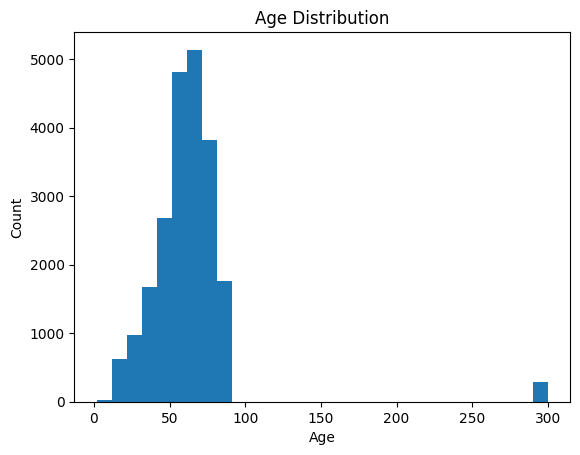

In [156]:
print("Age statistics:")
print(df["age"].describe())

import matplotlib.pyplot as plt

plt.hist(df["age"].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


For patients with ECGs taken at an age of 90 or older, age is set to 300 years to comply with Health Insurance Portability and Accountability Act (HIPAA) standards.

In [157]:
sex_counts = df["sex"].value_counts()
print("Sex distribution:")
print(sex_counts)

print("\nPercentages:")
print(df["sex"].value_counts(normalize=True) * 100)

df["sex_label"] = df["sex"].map({0: "Female", 1: "Male"})
print(df["sex_label"].value_counts())


Sex distribution:
sex
0    11354
1    10445
Name: count, dtype: int64

Percentages:
sex
0    52.084958
1    47.915042
Name: proportion, dtype: float64
sex_label
Female    11354
Male      10445
Name: count, dtype: int64


### 2.3. Arrhythmia / Diagnostic Analysis

In [158]:
# Load full mapping once
scp_all = pd.read_csv(path + "scp_statements.csv", index_col=0)

# Separate views for each use
diag_df   = scp_all[scp_all.diagnostic == 1]
form_df   = scp_all[scp_all.form == 1]
rhythm_df = scp_all[scp_all.rhythm == 1]

# Ensure scp_codes are dicts
if isinstance(df["scp_codes"].iloc[0], str):
    df["scp_codes"] = df["scp_codes"].apply(ast.literal_eval)

# Helper
def aggregate_labels(y_dic, mapping_df, column_name):
    tmp = []
    for key in y_dic.keys():
        if key in mapping_df.index:
            val = mapping_df.loc[key, column_name]
            if isinstance(val, pd.Series):
                tmp.extend(list(val))
            else:
                tmp.append(val)
    return list(set([str(v) for v in tmp]))


Diagnostic superclass distribution:
NORM : 9514
MI : 5469
STTC : 5235
HYP : 2649
CD : 4898


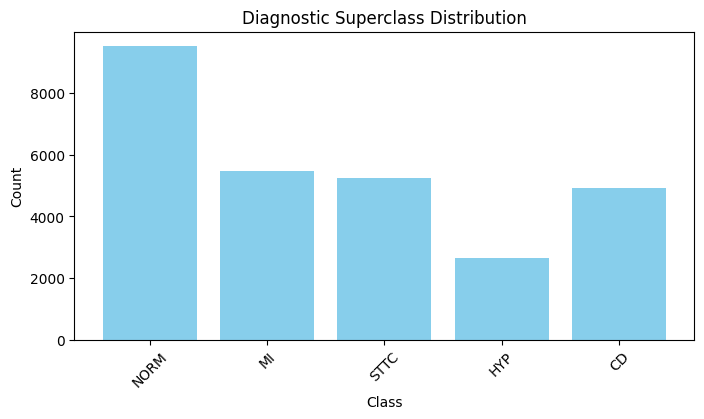

In [159]:
# 1. Diagnostic superclass

df["diagnostic_superclass"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, diag_df, "diagnostic_class")
)

all_labels = [label for sublist in df["diagnostic_superclass"] for label in sublist]
label_counts = Counter(all_labels)

print("Diagnostic superclass distribution:")
for k, v in label_counts.items():
    print(k, ":", v)

plt.figure(figsize=(8,4))
plt.bar(label_counts.keys(), label_counts.values(), color='skyblue')
plt.xticks(rotation=45)
plt.title("Diagnostic Superclass Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()



Diagnostic subclass distribution:
NORM : 9514
nan : 21194
IMI : 3271
STTC : 2239
NST_ : 767
LVH : 2132
LAFB/LPFB : 1797
RAO/RAE : 99
RVH : 126
IRBBB : 1118
IVCD : 787
LMI : 201
AMI : 3078
_AVB : 823
ISCA : 941
SEHYP : 29
ISCI : 397
ISC_ : 1272
CRBBB : 541
CLBBB : 536
LAO/LAE : 426
ILBBB : 77
PMI : 17
WPW : 79


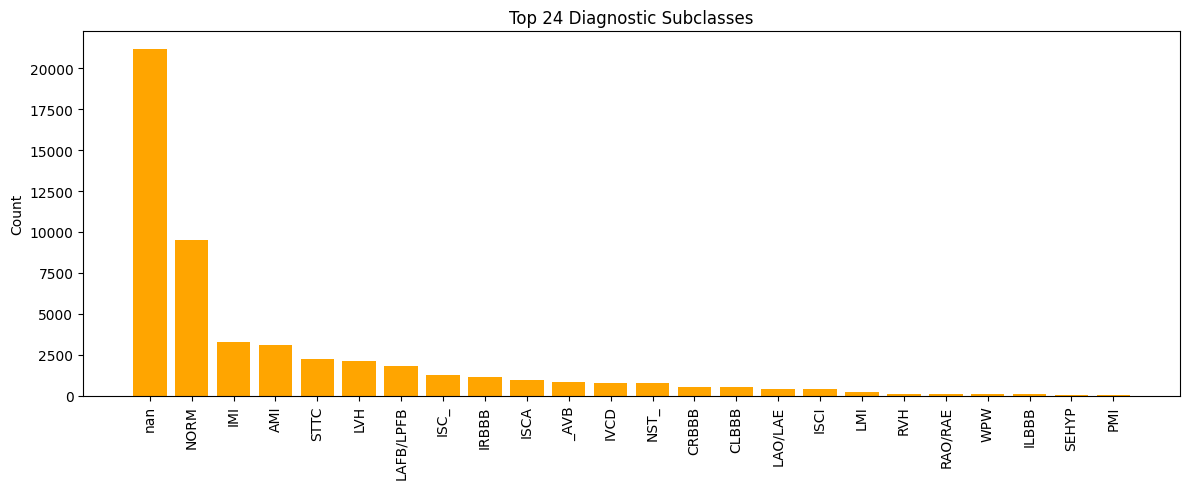

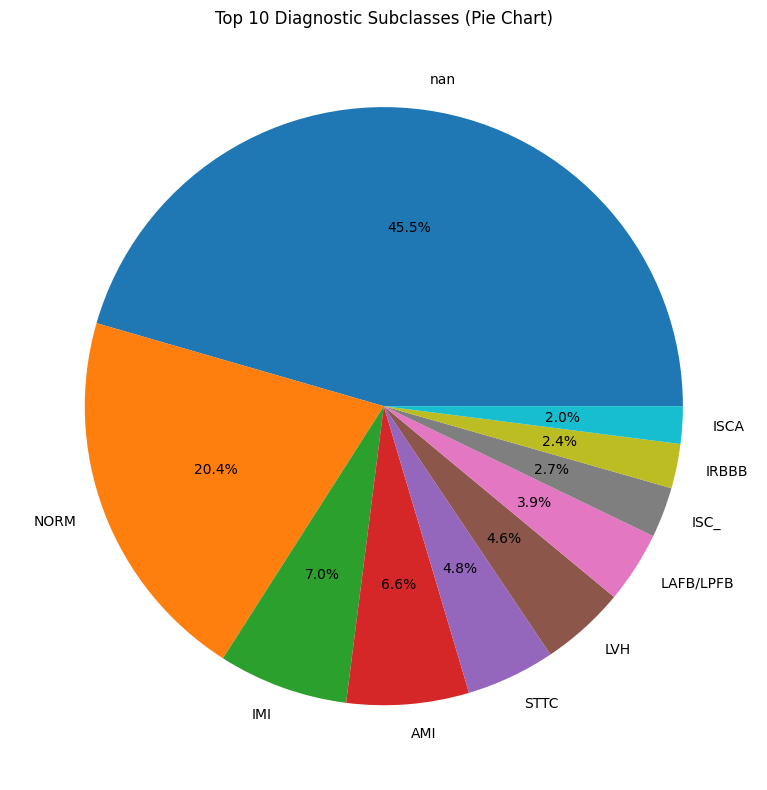

In [176]:
# 2. Diagnostic subclass

df["diagnostic_subclass"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, scp_all, "diagnostic_subclass")
)

all_labels = [label for sublist in df["diagnostic_subclass"] for label in sublist]
label_counts = Counter(all_labels)

print("\nDiagnostic subclass distribution:")
for k, v in label_counts.items():
    print(k, ":", v)

top_n = 24
top_items = dict(label_counts.most_common(top_n))

plt.figure(figsize=(12,5))
plt.bar(top_items.keys(), top_items.values(), color='orange')
plt.xticks(rotation=90)
plt.title(f"Top {top_n} Diagnostic Subclasses")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart of top subclasses
top_n = 10
top_items = dict(label_counts.most_common(top_n))

plt.figure(figsize=(8,8))
plt.pie(top_items.values(), labels=top_items.keys(), autopct="%1.1f%%")
plt.title(f"Top {top_n} Diagnostic Subclasses (Pie Chart)")
plt.tight_layout()
plt.show()



Form distribution:
low QRS voltages in the frontal and horizontal leads : 182
abnormal QRS : 3327
non-diagnostic T abnormalities : 1825
digitalis-effect : 181
non-specific ST changes : 767
long QT-interval : 117
ventricular premature complex : 1143
T-wave abnormality : 35
high QRS voltage : 62
low amplitude T-waves : 438
non-specific ST depression : 1009
atrial premature complex : 398
non-specific T-wave changes : 423
Q waves present : 548
inverted T-waves : 294
prolonged PR interval : 340
voltage criteria (QRS) for left ventricular hypertrophy : 875
premature complex(es) : 10
non-specific ST elevation : 28


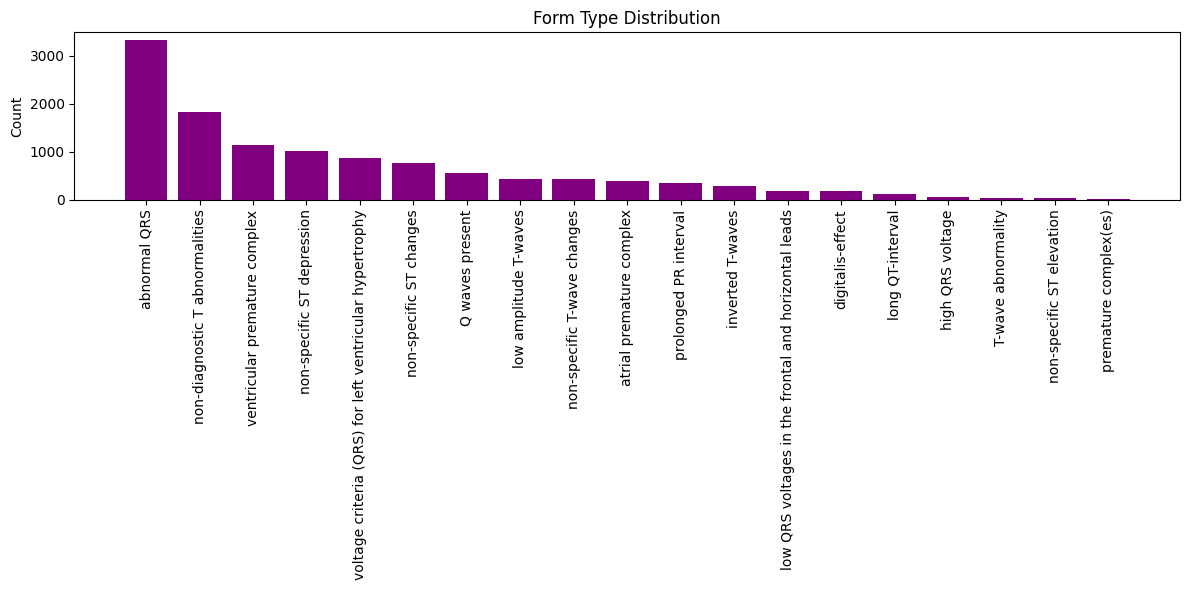

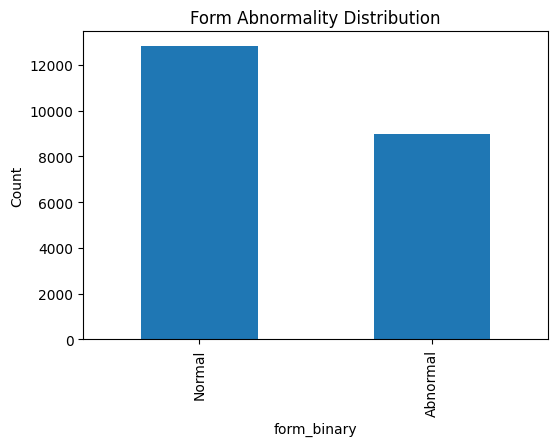


Form abnormality percentage:
form_binary
0    58.814625
1    41.185375
Name: proportion, dtype: float64


In [180]:
# 3. Form

# Extract form labels
df["form"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, form_df, "description")
)

# Flatten for counting
all_forms = [label for sublist in df["form"] for label in sublist]
form_counts = Counter(all_forms)

print("\nForm distribution:")
for k, v in form_counts.items():
    print(k, ":", v)

# Categorical form distribution

plt.figure(figsize=(12,6))
sorted_form_counts = dict(sorted(form_counts.items(), key=lambda x: x[1], reverse=True))

plt.bar(sorted_form_counts.keys(), sorted_form_counts.values(), color="purple")
plt.xticks(rotation=90)
plt.title("Form Type Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Binary form abnormality

df["form_binary"] = df["form"].apply(lambda x: 1 if len(x) > 0 else 0)

plt.figure(figsize=(6,4))
df["form_binary"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1], ["Normal", "Abnormal"])
plt.title("Form Abnormality Distribution")
plt.ylabel("Count")
plt.show()

print("\nForm abnormality percentage:")
print(df["form_binary"].value_counts(normalize=True) * 100)



Rhythm distribution:
sinus rhythm : 16748
sinus bradycardia : 637
sinus arrhythmia : 772
atrial flutter : 73
atrial fibrillation : 1514
sinus tachycardia : 826
normal functioning artificial pacemaker : 294
supraventricular tachycardia : 27
bigeminal pattern (unknown origin, SV or Ventricular) : 82
trigeminal pattern (unknown origin, SV or Ventricular) : 20
paroxysmal supraventricular tachycardia : 24
supraventricular arrhythmia : 157

Rhythm code presence percentage:
rhythm_binary
1    96.472315
0     3.527685
Name: proportion, dtype: float64


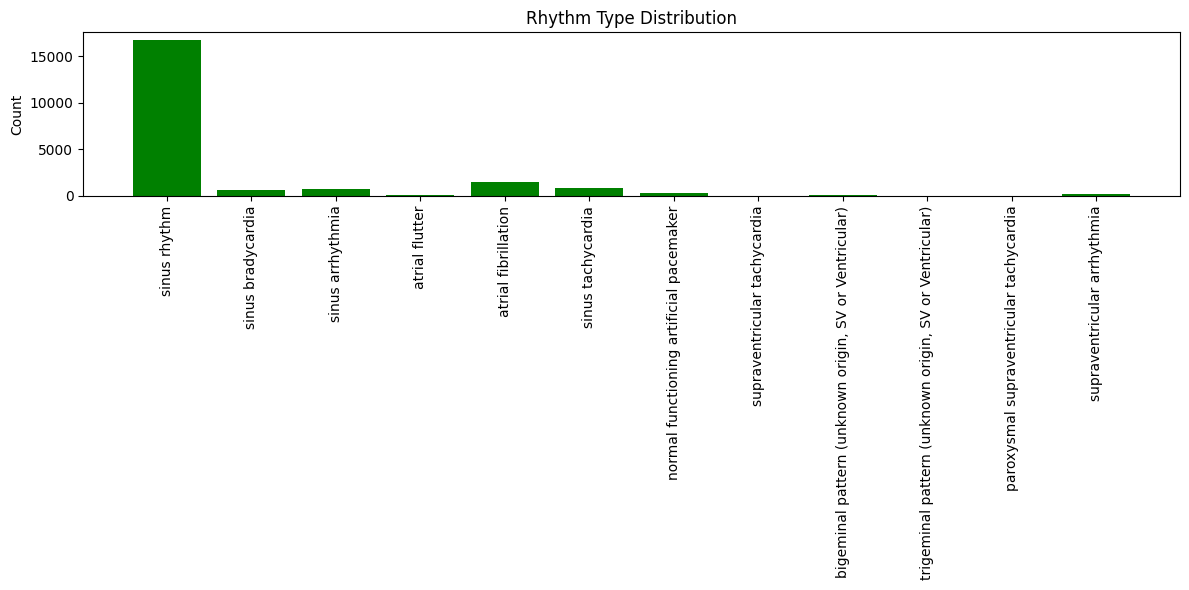

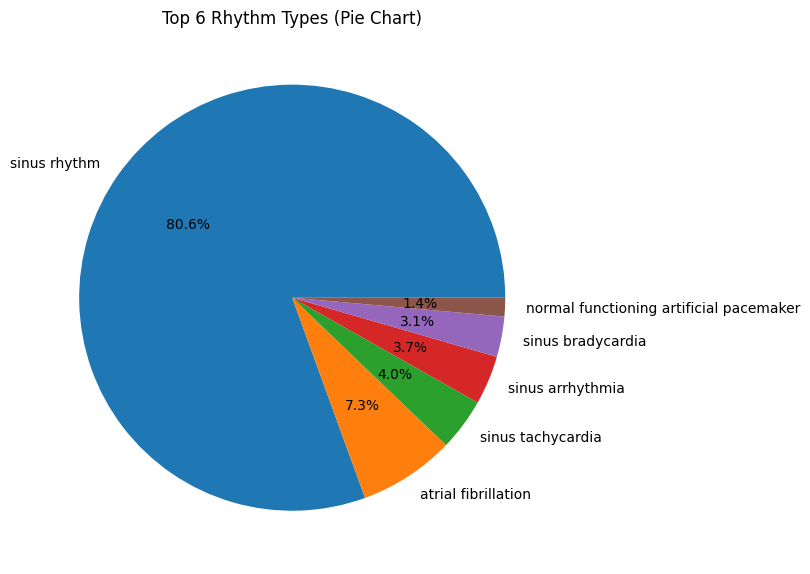

In [181]:
# 4. Rhythm

df["rhythm"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, rhythm_df, "description")
)

all_rhythm = [label for sublist in df["rhythm"] for label in sublist]
rhythm_counts = Counter(all_rhythm)

print("\nRhythm distribution:")
for k, v in rhythm_counts.items():
    print(k, ":", v)

# Binary: presence of any rhythm label
df["rhythm_binary"] = df["rhythm"].apply(lambda x: 1 if len(x) > 0 else 0)

print("\nRhythm code presence percentage:")
print(df["rhythm_binary"].value_counts(normalize=True) * 100)

plt.figure(figsize=(12,6))
plt.bar(rhythm_counts.keys(), rhythm_counts.values(), color="green")
plt.xticks(rotation=90)
plt.title("Rhythm Type Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Pie chart of top rhythm types
top_n = 6
top_rhythm = dict(rhythm_counts.most_common(top_n))

plt.figure(figsize=(8,8))
plt.pie(top_rhythm.values(), labels=top_rhythm.keys(), autopct="%1.1f%%")
plt.title(f"Top {top_n} Rhythm Types (Pie Chart)")
plt.tight_layout()
plt.show()



SCP-ECG Statement distribution (all shown):
sinus rhythm : 16748
low QRS voltages in the frontal and horizontal leads : 182
normal ECG : 9514
sinus bradycardia : 637
inferior myocardial infarction : 2676
abnormal QRS : 3327
sinus arrhythmia : 772
atrial flutter : 73
atrial fibrillation : 1514
non-diagnostic T abnormalities : 1825
suggests digitalis-effect : 181
non-specific ST changes : 767
left ventricular hypertrophy : 2132
left posterior fascicular block : 177
long QT-interval : 117
left anterior fascicular block : 1623
right atrial overload/enlargement : 99
incomplete right bundle branch block : 1118
right ventricular hypertrophy : 126
non-specific intraventricular conduction disturbance : 787
lateral myocardial infarction : 201
anteroseptal myocardial infarction : 2357
anterior myocardial infarction : 353
first degree AV block : 793
in anterolateral leads : 804
sinus tachycardia : 826
normal functioning artificial pacemaker : 294
in lateral leads : 157
septal hypertrophy : 29
in 

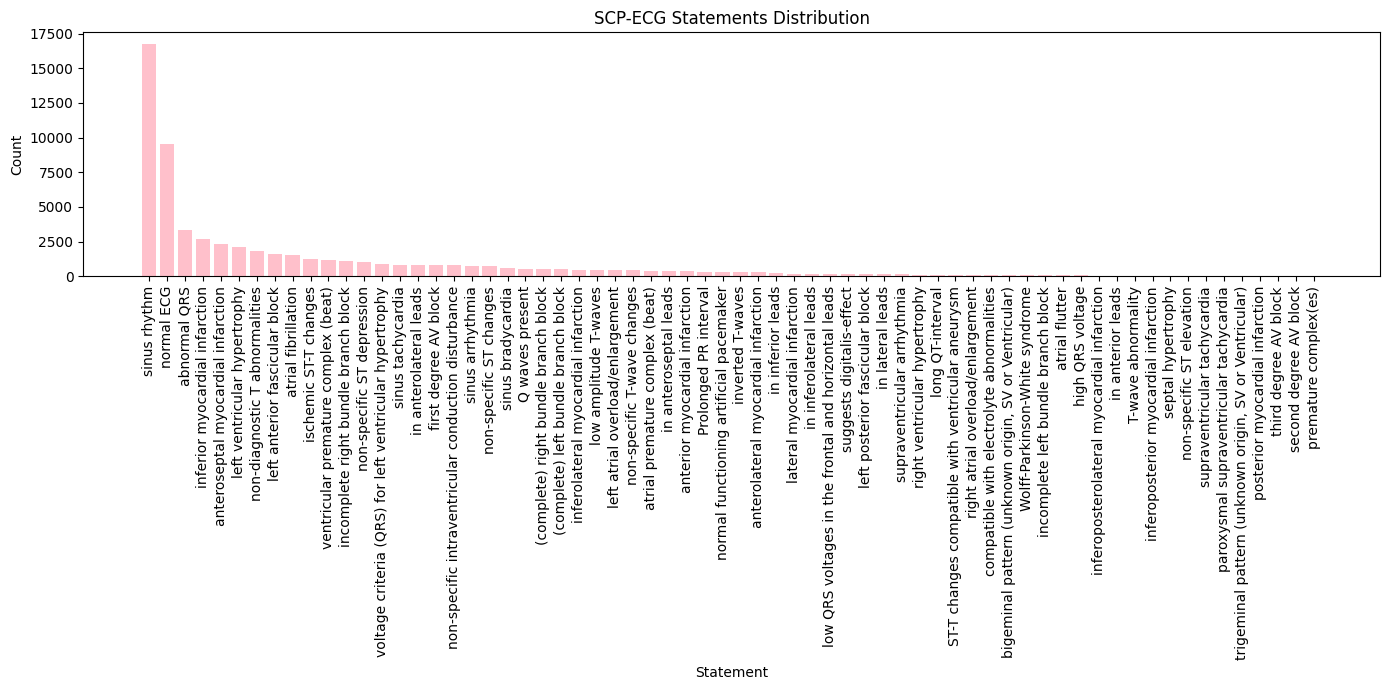

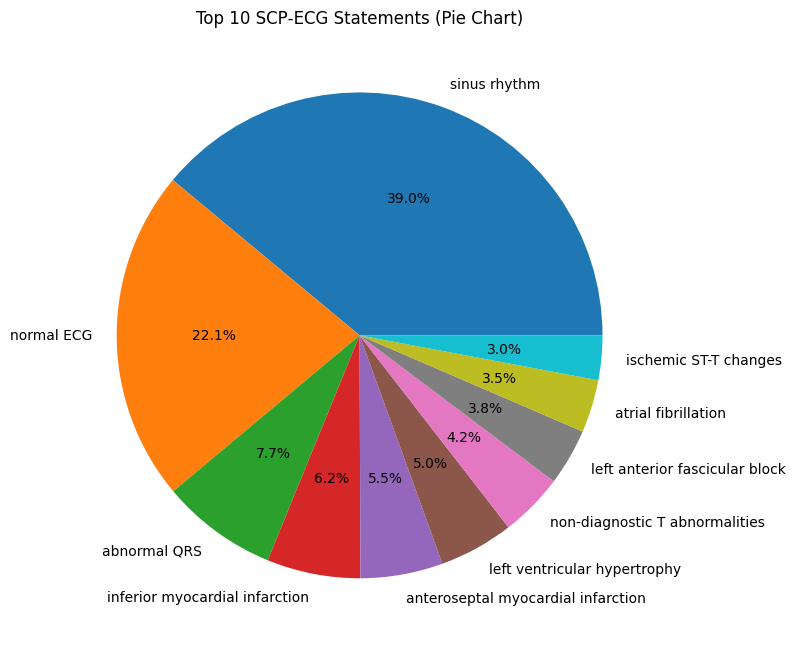

In [184]:
# 5. SCP-ECG statements

# Use the full mapping table, not the diagnostic-filtered one
df["scp_statements"] = df["scp_codes"].apply(
    lambda x: aggregate_labels(x, scp_all, "SCP-ECG Statement Description")
)

all_labels = [str(label) for sublist in df["scp_statements"] for label in sublist]
label_counts = Counter(all_labels)

print("\nSCP-ECG Statement distribution (all shown):")
for k, v in label_counts.items():
    print(k, ":", v)

plt.figure(figsize=(14,7))

# Sort by frequency for readability
sorted_counts = dict(sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

plt.bar(sorted_counts.keys(), sorted_counts.values(), color="pink")
plt.xticks(rotation=90)
plt.title("SCP-ECG Statements Distribution")
plt.xlabel("Statement")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


# Pie chart of top categories
top_n = 10
top_items = dict(label_counts.most_common(top_n))

plt.figure(figsize=(8,8))
plt.pie(top_items.values(), labels=top_items.keys(), autopct="%1.1f%%")
plt.title(f"Top {top_n} SCP‑ECG Statements (Pie Chart)")
plt.tight_layout()
plt.show()


### 2.4. 12‑lead ECG example

Sampling frequency: 100
Signal shape (samples × leads): (1000, 12)
Lead names: ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


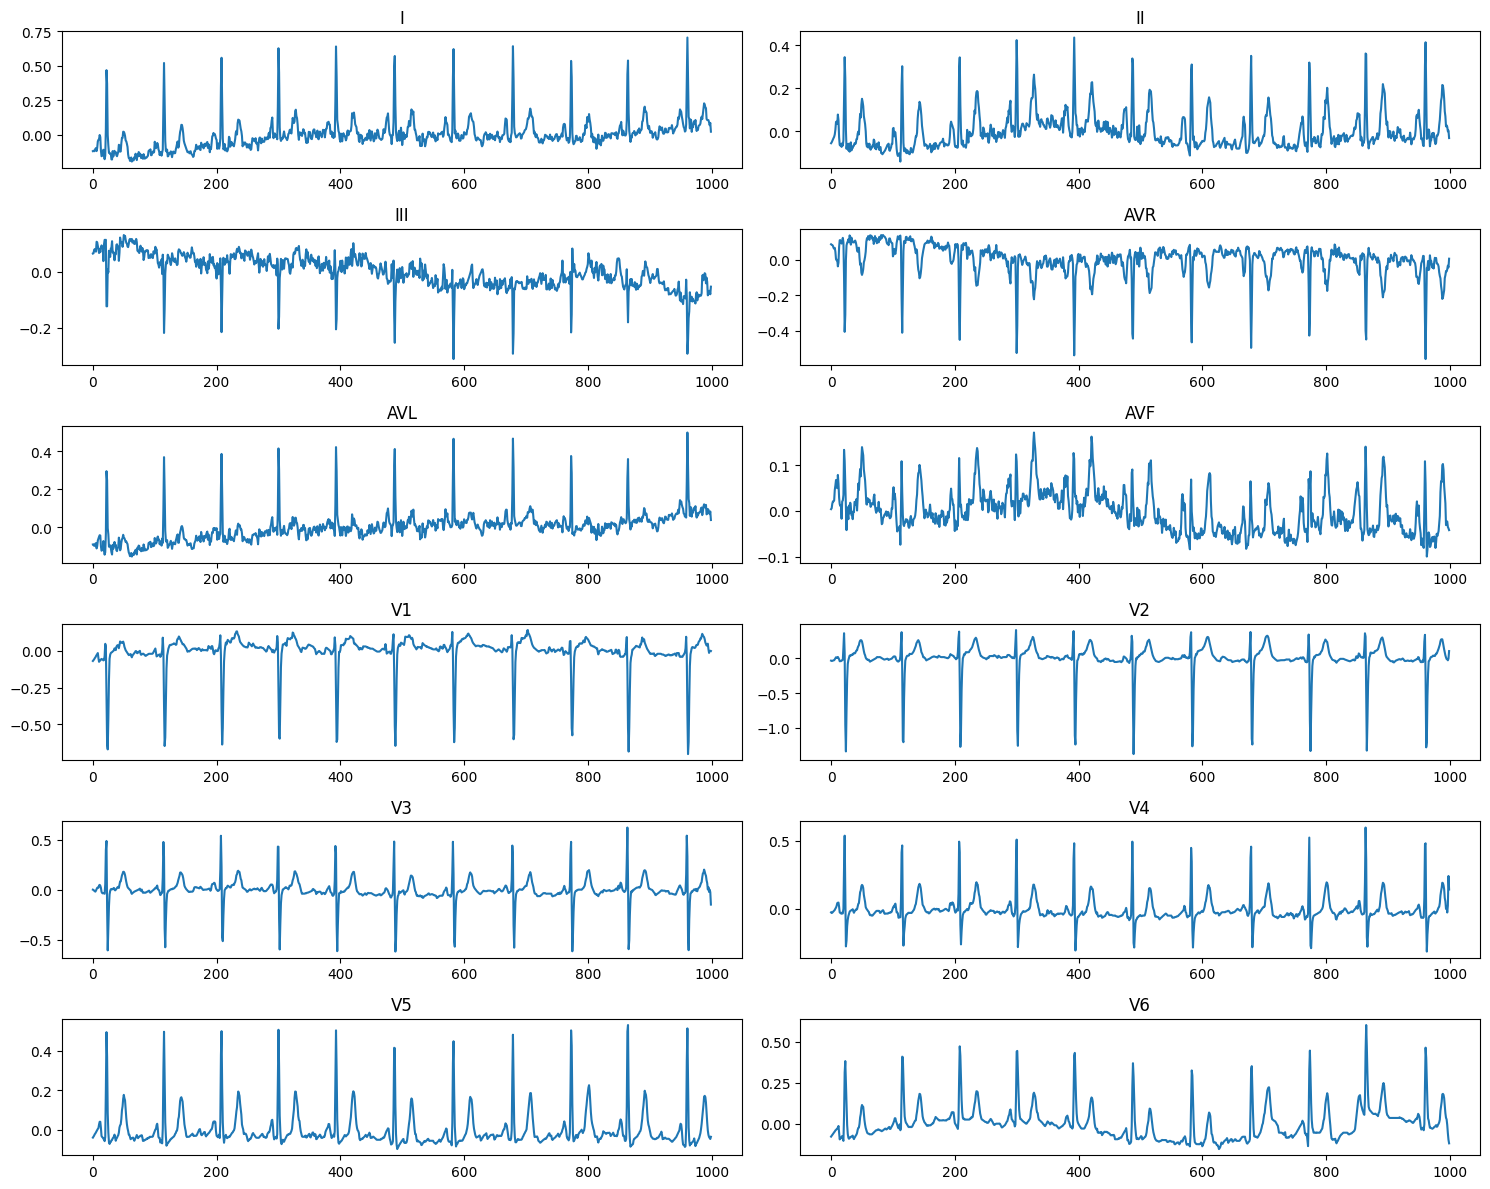

In [164]:
# Load metadata
df = pd.read_csv(path + "ptbxl_database.csv", index_col="ecg_id")
df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))

# Pick one ECG example
example_id = 1
record_path = path + df.loc[example_id].filename_lr  # low‑resolution (100 Hz)

# Load the 12‑lead ECG
signal, meta = wfdb.rdsamp(record_path)

print("Sampling frequency:", meta['fs'])
print("Signal shape (samples × leads):", signal.shape)
print("Lead names:", meta['sig_name'])

# Plot all 12 leads
plt.figure(figsize=(15, 12))
for i in range(12):
    plt.subplot(6, 2, i+1)
    plt.plot(signal[:, i])
    plt.title(meta['sig_name'][i])
    plt.tight_layout()

plt.show()
